# Check posterior means of proposed model


In [17]:
import sys
from pathlib import Path

# Add project root to path
sys.path.append(str(Path("..").resolve()))

from typing import List, Literal
from helpers import Model, load_fitted_model
import arviz as az
import matplotlib.pyplot as plt
import numpy as np

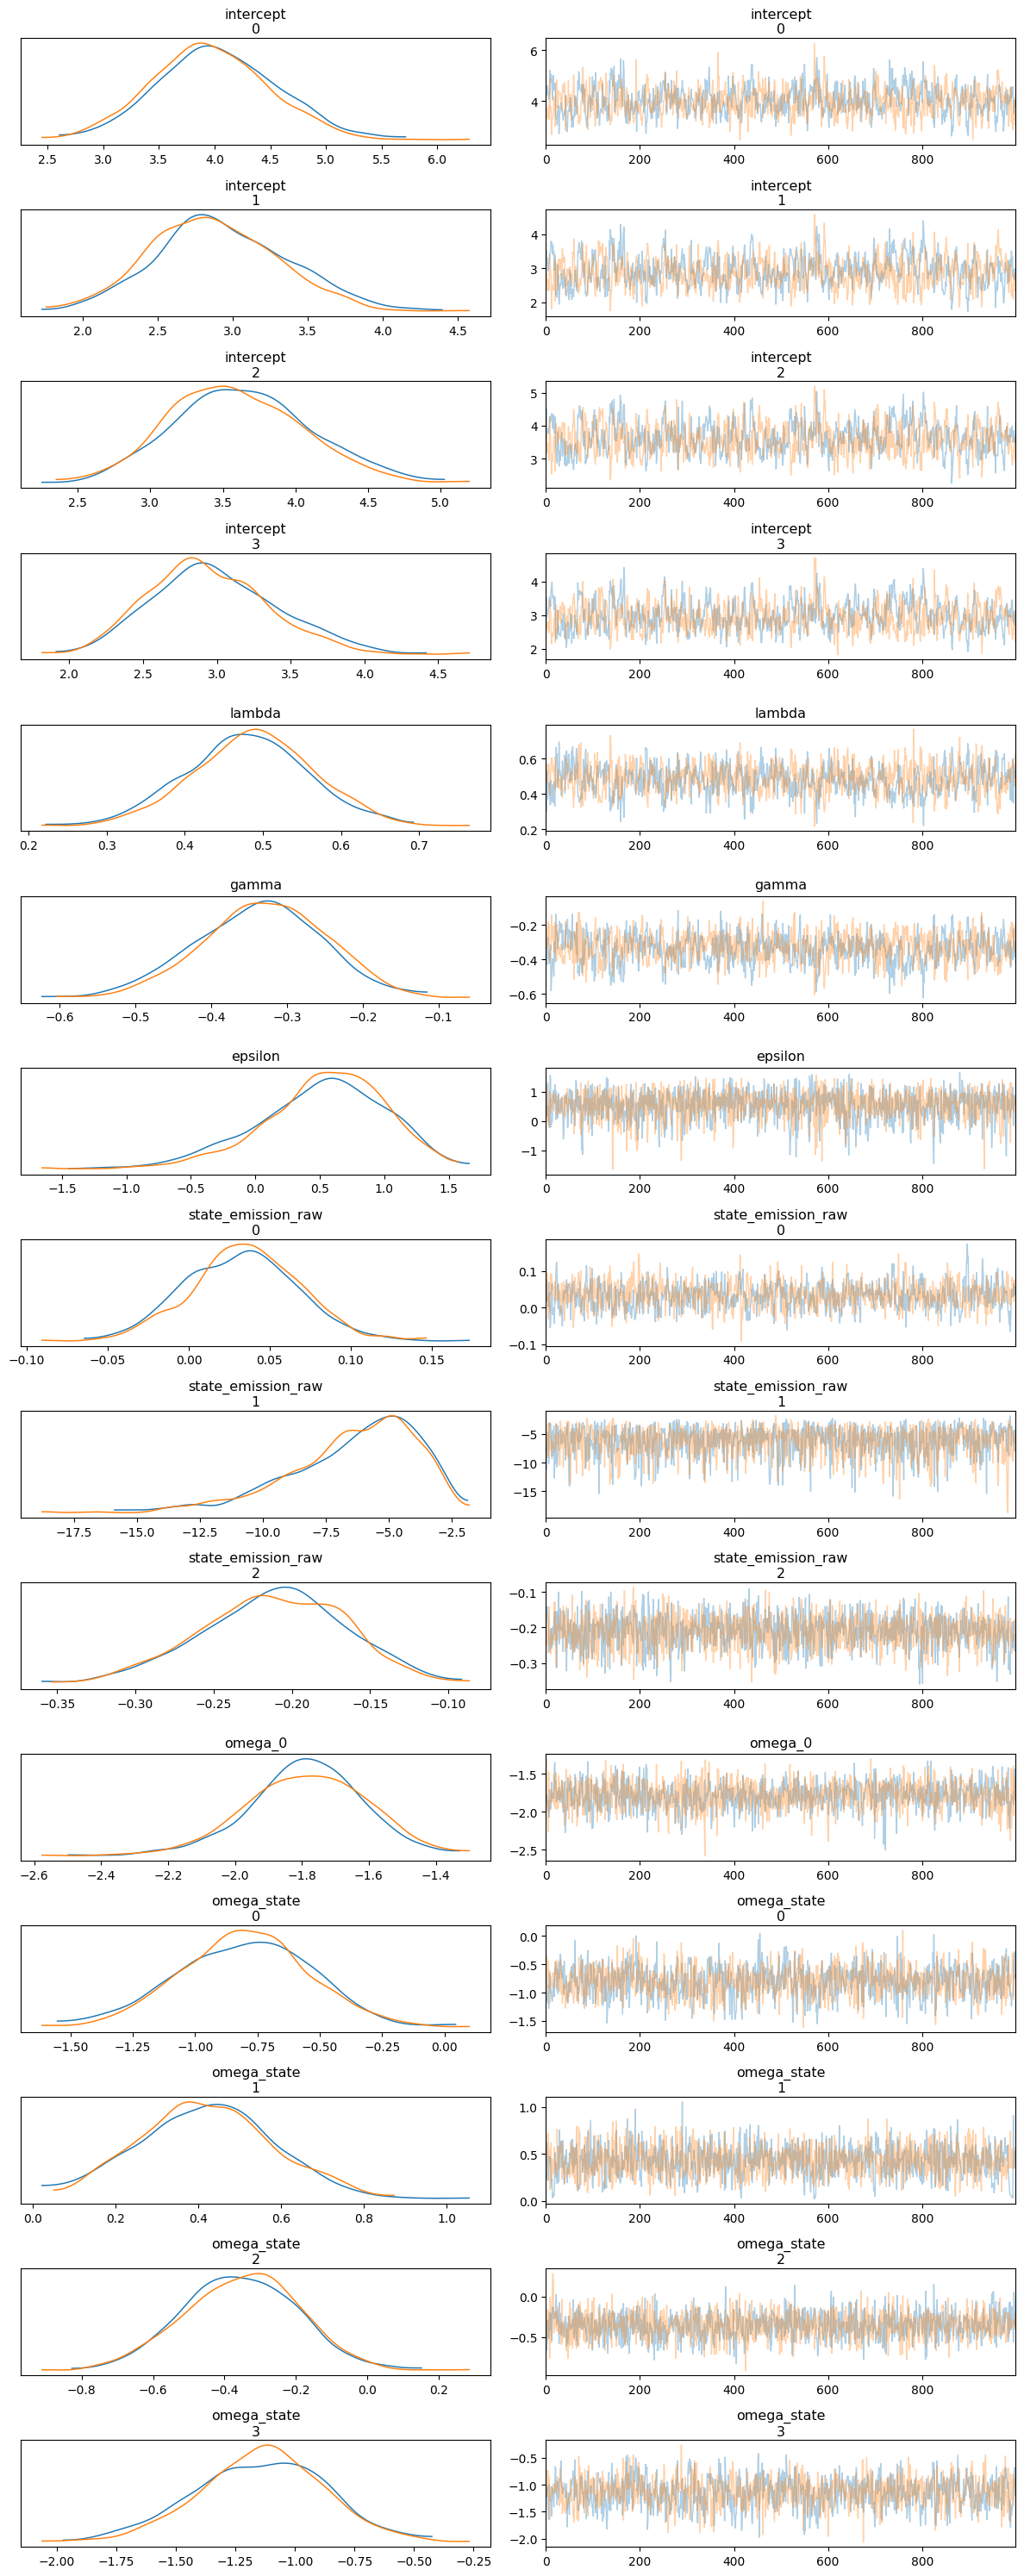

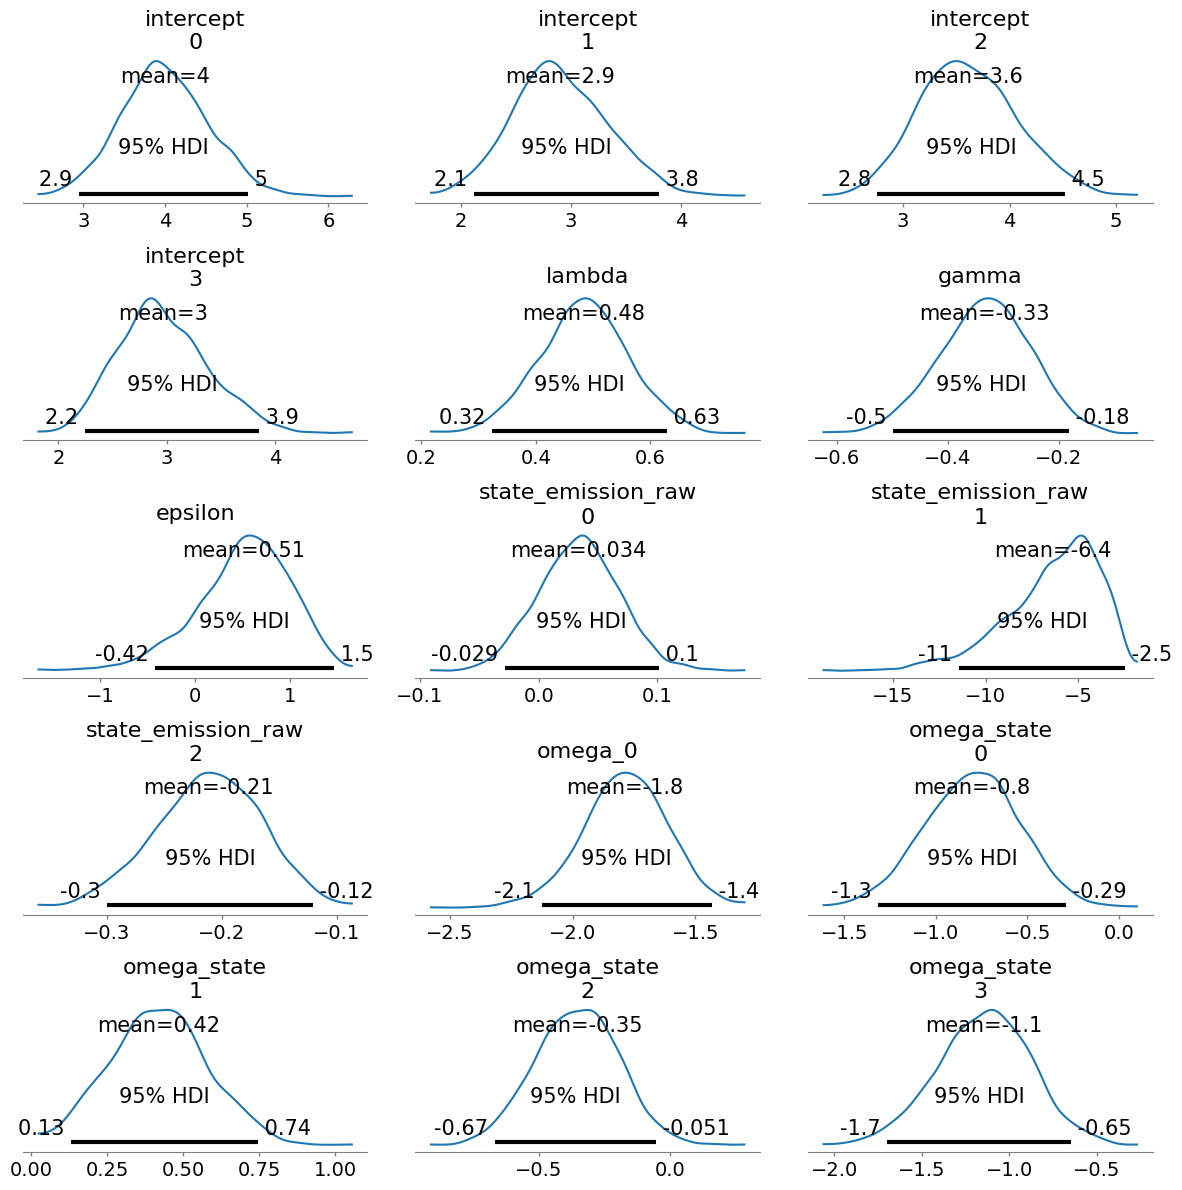

In [18]:
az.rcParams["stats.ci_prob"] = 0.95  # set set Credible Interval to 95%


def plot_posterior_distributions(
    model: Model,
    var_names: List[str] = [
        "intercept",
        "lambda",
        "gamma",
        "epsilon",
        "state_emission_raw",
        "omega_0",
        "omega_state",
    ],
    get_chain_progression: bool | Literal["both"] = True,
):

    inference_data = az.from_cmdstanpy(model.fit)

    if get_chain_progression:
        az.plot_trace(
            inference_data,
            var_names=var_names,
            compact=False,
        )
        plt.tight_layout()
        plt.show()

    az.plot_posterior(inference_data, var_names=var_names, figsize=(12, 12))
    plt.tight_layout()
    plt.show()


proposed_model = load_fitted_model("vdhmm", S=4)

plot_posterior_distributions(proposed_model)

In [19]:
def get_state_failure_posterior_means(model: Model):

    column_names = [
        "Intercept omega_0",
        *[f"omega_{s}" for s in range(1, model.S + 1)],
        "density",
        "Checkin",
        "category_American",
        "category_Asian",
        "category_Cafes",
        "category_Fast Food",
        "category_Mexican",
        "category_Pizza",
        "category_Salad",
        "category_Speciality Food",
        "chain",
        "Price.Level",
        "Restaurant.Size",
        "Number.of.Seats",
        "ZRI",
        "Age",
    ]
    df = model.summary[["Mean", "StdDev", "5%", "95%", "R_hat"]]
    df_filtered = df[
        df.index.str.contains("omega_0")
        | df.index.str.contains(r"omega_state\[")
        | df.index.str.contains(r"omega_cov\[")
    ].round(4)

    significance_list = []

    draws_pd = model.fit.draws_pd()

    for idx, row in df_filtered.iterrows():
        parameter_samples = draws_pd[row.name]
        percentiles_95 = np.percentile(parameter_samples, [2.5, 97.5])
        percentiles_99 = np.percentile(parameter_samples, [0.5, 99.5])
        percentiles_999 = np.percentile(parameter_samples, [0.05, 99.95])

        # Check if the credible interval excludes zero
        if not percentiles_999[0] <= 0 <= percentiles_999[1]:
            significance_list.append("***p < 0.001")
        elif not percentiles_99[0] <= 0 <= percentiles_99[1]:
            significance_list.append("**p < 0.01")
        elif not percentiles_95[0] <= 0 <= percentiles_95[1]:
            significance_list.append("*p < 0.05")
        else:
            significance_list.append("X")

    df_filtered.insert(0, "Name", column_names)
    df_filtered["significance"] = significance_list

    return df_filtered


def get_hazard_posterior_means(
    model: Model,
    var_names=["intercept", "lambda", "gamma", "epsilon"],
):
    """
    Extract posterior means for hazard function parameters (self-transition probabilities).

    Parameters in the VD-HMM hazard function:
    - intercept[s] (λ₀^s): State-specific baseline hazard
    - lambda (λ₁): Effect of state duration (log-transformed)
    - gamma (λ₂): Effect of time difference between ratings (log-transformed)
    - epsilon (λ₃): Effect of review sentiment

    The self-transition probability is modeled as:
    γₛ(dⱼ, Δⱼ,ⱼ₊₁, σᵢⱼ) = logit⁻¹(λ₀^s + λ₁·log(1+dⱼ(s)) + λ₂·log(1+Δⱼ,ⱼ₊₁) + λ₃·σᵢⱼ)
    """
    df = model.summary[["Mean", "StdDev", "5%", "95%", "R_hat"]]

    # Filter for hazard parameters
    df_filtered = df[
        df.index.str.contains(r"^intercept\[")  # State-specific intercepts
        | df.index.str.contains(r"^lambda$")  # Duration effect
        | df.index.str.contains(r"^gamma$")  # Time difference effect
        | df.index.str.contains(r"^epsilon$")  # Sentiment effect
    ].round(4)

    # Create proper names
    hazard_names = []
    for idx in df_filtered.index:
        if "intercept[" in idx:
            # Extract state number
            state_num = idx.split("[")[1].split("]")[0]
            hazard_names.append(f"λ₀^{state_num} (Intercept State {state_num})")
        elif idx == "lambda":
            hazard_names.append("λ₁ (Duration Effect)")
        elif idx == "gamma":
            hazard_names.append("λ₂ (Time Difference Effect)")
        elif idx == "epsilon":
            hazard_names.append("λ₃ (Sentiment Effect)")

    # Calculate significance
    significance_list = []
    draws_pd = model.fit.draws_pd()

    for idx, row in df_filtered.iterrows():
        parameter_samples = draws_pd[row.name]
        percentiles_95 = np.percentile(parameter_samples, [2.5, 97.5])
        percentiles_99 = np.percentile(parameter_samples, [0.5, 99.5])
        percentiles_999 = np.percentile(parameter_samples, [0.05, 99.95])

        # Check if the credible interval excludes zero
        if not percentiles_999[0] <= 0 <= percentiles_999[1]:
            significance_list.append("***p < 0.001")
        elif not percentiles_99[0] <= 0 <= percentiles_99[1]:
            significance_list.append("**p < 0.01")
        elif not percentiles_95[0] <= 0 <= percentiles_95[1]:
            significance_list.append("*p < 0.05")
        else:
            significance_list.append("X")

    df_filtered.insert(0, "Parameter", hazard_names)
    df_filtered["Significance"] = significance_list

    return df_filtered


# Test both functions
print("=" * 80)
print("STATE-FAILURE EMISSION PARAMETERS (Table 4)")
print("=" * 80)
display(get_state_failure_posterior_means(proposed_model))

print("\n" + "=" * 80)
print("HAZARD FUNCTION PARAMETERS (Self-Transition Probabilities)")
print("=" * 80)
display(get_hazard_posterior_means(proposed_model))

STATE-FAILURE EMISSION PARAMETERS (Table 4)


,Name,Mean,StdDev,5%,95%,R_hat,significance
omega_0,Intercept omega_0,-1.7866,0.1761,-2.0869,-1.5091,1.0030,***p < 0.001
omega_state[1],omega_1,-0.8022,0.2639,-1.2412,-0.3743,1.0013,**p < 0.01
omega_state[2],omega_2,0.4198,0.1601,0.1571,0.6922,1.0012,***p < 0.001
omega_state[3],omega_3,-0.3532,0.1595,-0.6202,-0.0954,1.0017,*p < 0.05
omega_state[4],omega_4,-1.1435,0.2675,-1.5955,-0.7112,1.0028,***p < 0.001
omega_cov[1],density,0.0020,0.0086,-0.0123,0.0166,1.0008,X
omega_cov[2],Checkin,-0.0119,0.0220,-0.0487,0.0239,1.0024,X
omega_cov[3],category_American,-0.6856,0.5033,-1.4972,0.1451,1.0000,X
omega_cov[4],category_Asian,-0.2381,0.5780,-1.1892,0.7154,1.0006,X
omega_cov[5],category_Cafes,-0.2671,0.6030,-1.2633,0.7387,0.9994,X



HAZARD FUNCTION PARAMETERS (Self-Transition Probabilities)


,Parameter,Mean,StdDev,5%,95%,R_hat,Significance
intercept[1],λ₀^1 (Intercept State 1),3.9983,0.5352,3.1353,4.8812,1.0035,***p < 0.001
intercept[2],λ₀^2 (Intercept State 2),2.9041,0.4356,2.2118,3.6692,1.0054,***p < 0.001
intercept[3],λ₀^3 (Intercept State 3),3.6142,0.4609,2.8785,4.4080,1.0037,***p < 0.001
intercept[4],λ₀^4 (Intercept State 4),2.9696,0.4217,2.3380,3.7236,1.0044,***p < 0.001
lambda,λ₁ (Duration Effect),0.4837,0.0782,0.3523,0.6135,1.0036,***p < 0.001
gamma,λ₂ (Time Difference Effect),-0.3332,0.0821,-0.4726,-0.2014,1.0029,***p < 0.001
epsilon,λ₃ (Sentiment Effect),0.5149,0.4957,-0.3974,1.2392,1.0014,X


In [20]:
# =============================================================================
# STATE-RATING DISTRIBUTION TABLE
# =============================================================================
import numpy as np
import pandas as pd
from scipy.special import expit
from scipy.stats import norm


def calculate_state_dependent_rating_dist(model: Model):
    # =============================================================================
    # 1. EXTRACT EMISSION PARAMETERS FROM STAN MODEL
    # =============================================================================

    summary = model.summary
    S = model.S

    # Extract state_emission_raw (η_s raw values for S-1 states)
    state_emission_raw = [
        summary.loc[f"state_emission_raw[{s}]", "Mean"] for s in range(1, S)
    ]

    # Extract R2 values (variance scaling for all S states)
    R2_values = [summary.loc[f"R2[{s}]", "Mean"] for s in range(1, S + 1)]

    # Extract probs (simplex for 5 rating categories)
    probs = [summary.loc[f"probs[{r}]", "Mean"] for r in range(1, 5)]

    # =============================================================================
    # 2. CALCULATE STATE EMISSIONS (η_s)
    # =============================================================================

    # Transform state_emission_raw to state_emission using cumulative sum with exp
    # Following Stan code: state_emission[s] = state_emission[s-1] + exp(state_emission_raw[s-1])
    state_emission = [0.0]  # First state is reference (η_1 = 0)
    for raw_val in state_emission_raw:
        state_emission.append(state_emission[-1] + np.exp(raw_val))

    # =============================================================================
    # 3. CALCULATE ORDERED PROBIT EMISSION PROBABILITIES
    # =============================================================================

    # Initialize DataFrame for emission probabilities
    emission_probs_pct = pd.DataFrame(
        index=[f"State {s+1}" for s in range(S)],
        columns=["5 stars", "4 stars", "3 stars", "2 stars", "1 star"],
    )

    # Calculate cumulative probabilities for cut points
    cumsum_probs = np.cumsum(probs)

    # Calculate emission probabilities for each state
    for s in range(S):
        # Calculate scale factor from R2 (variance explained)
        scale = 1 / np.sqrt(1 - expit(R2_values[s]))

        # Calculate cut points using inverse normal CDF
        cuts = scale * norm.ppf(cumsum_probs)

        # Get state emission parameter (η_s)
        eta = state_emission[s]

        # Calculate ordered probit probabilities
        emission_probs_pct.iloc[s, 0] = norm.cdf(eta - cuts[3])  # P(Rating = 5)
        for r in range(1, 4):  # P(Rating = 4, 3, 2)
            emission_probs_pct.iloc[s, r] = norm.cdf(eta - cuts[3 - r]) - norm.cdf(
                eta - cuts[4 - r]
            )
        emission_probs_pct.iloc[s, 4] = 1 - norm.cdf(eta - cuts[0])  # P(Rating = 1)

    # Convert to percentages
    emission_probs_pct = emission_probs_pct.astype(float) * 100

    # =============================================================================
    # 4. CALCULATE MEAN RATINGS, STDDEV, AND ENTROPY PER STATE
    # =============================================================================

    mean_ratings_per_state = []
    stddev_per_state = []
    entropy_per_state = []

    for s in range(S):
        # Get probability array for this state (convert from percentage to probability)
        probs_array = emission_probs_pct.iloc[s].values / 100
        ratings = np.array([5, 4, 3, 2, 1])

        # Calculate mean rating
        mean_rating = np.sum(ratings * probs_array)
        mean_ratings_per_state.append(mean_rating)

        # Calculate standard deviation: σ = sqrt(E[X²] - μ²)
        variance = np.sum((ratings**2) * probs_array) - mean_rating**2
        std_dev = np.sqrt(variance)
        stddev_per_state.append(std_dev)

        # Calculate Shannon entropy: H = -Σ(p * log2(p)) for non-zero probabilities
        probs_nonzero = probs_array[probs_array > 0]
        entropy = -np.sum(probs_nonzero * np.log2(probs_nonzero))
        entropy_per_state.append(entropy)

    emission_probs_pct["Mean Rating"] = mean_ratings_per_state
    emission_probs_pct["StdDev"] = stddev_per_state
    emission_probs_pct["Entropy"] = entropy_per_state

    # =============================================================================
    # 5. IDENTIFY AND LABEL STATES
    # =============================================================================

    # Extract omega_state coefficients (state-specific failure effects)
    omega_state_values = [summary.loc[f"omega_state[{s+1}]", "Mean"] for s in range(S)]

    # Sort states by mean rating (descending)
    state_order_by_rating = np.argsort(mean_ratings_per_state)[::-1]

    state_labels = []
    for idx in state_order_by_rating:
        state_labels.append(f"State {idx+1}")

    # =============================================================================
    # 6. CREATE FINAL TABLES
    # =============================================================================

    emission_probs_pct["omega_state"] = omega_state_values

    # Round appropriately: 2 decimals for percentages and mean, 3 for StdDev and Entropy
    emission_table_final = emission_probs_pct.copy()
    emission_table_final[
        [
            "5 stars",
            "4 stars",
            "3 stars",
            "2 stars",
            "1 star",
            "Mean Rating",
            "omega_state",
        ]
    ] = emission_table_final[
        [
            "5 stars",
            "4 stars",
            "3 stars",
            "2 stars",
            "1 star",
            "Mean Rating",
            "omega_state",
        ]
    ].round(
        2
    )
    emission_table_final[["StdDev", "Entropy"]] = emission_table_final[
        ["StdDev", "Entropy"]
    ].round(3)

    # =============================================================================
    # DISPLAY RESULTS
    # =============================================================================

    return emission_table_final


calculate_state_dependent_rating_dist(proposed_model)

,5 stars,4 stars,3 stars,2 stars,1 star,Mean Rating,StdDev,Entropy,omega_state
State 1,14.62,15.27,11.37,14.02,44.72,2.41,1.523,2.093,-0.80
State 2,22.75,32.89,18.92,15.05,10.40,3.43,1.274,2.219,0.42
State 3,45.90,22.01,10.81,9.37,11.91,3.81,1.406,2.029,-0.35
State 4,70.33,17.93,5.92,3.60,2.22,4.51,0.922,1.338,-1.14


# Table 5 Replication: Distribution of Recovered Latent States

---

## Latent State Recovery using Viterbi Algorithm

This section shows the distribution of recovered latent states at the end of the observation period and the failure rate for each state.


In [21]:
# =============================================================================
#  Distribution of Recovered Latent States
# =============================================================================

from cmdstanpy import CmdStanModel
import numpy as np
import pandas as pd
from helpers import Model
from constants import STAN_MODEL_FOLDER


def recover_latent_states(model: Model):

    # =============================================================================
    # 1. PREPARE DATA FOR VITERBI ALGORITHM
    # =============================================================================

    # Extract model parameters from posterior means (already learned from training)
    summary = model.summary
    S = model.S  # Get number of states dynamically

    # Extract initial state distribution (log probabilities) - DYNAMIC
    l_pi = [summary.loc[f"l_pi[{s}]", "Mean"] for s in range(1, S + 1)]

    # Extract transition probability matrix (log probabilities) - DYNAMIC
    l_tpm = np.zeros((S, S))  # ← Changed from (3, 3) to (S, S)
    for s_from in range(1, S + 1):
        for s_to in range(1, S + 1):
            l_tpm[s_from - 1, s_to - 1] = summary.loc[f"l_tpm[{s_from},{s_to}]", "Mean"]

    # Extract hazard function parameters - DYNAMIC
    intercept = [summary.loc[f"intercept[{s}]", "Mean"] for s in range(1, S + 1)]
    lambda_param = summary.loc["lambda", "Mean"]
    gamma_param = summary.loc["gamma", "Mean"]
    epsilon_param = summary.loc["epsilon", "Mean"]

    # Extract emission probabilities - DYNAMIC
    emission = np.zeros((S, 5))
    for s in range(1, S + 1):  # ← Changed from range(1, 4) to range(1, S + 1)
        for r in range(1, 6):
            emission[s - 1, r - 1] = summary.loc[f"emission[{s},{r}]", "Mean"]

    # =============================================================================
    # 2. COMPILE AND RUN VITERBI STAN MODEL (NO TRAINING, JUST COMPUTATION)
    # =============================================================================

    # Compile the Viterbi Stan model
    viterbi_stan_file = STAN_MODEL_FOLDER / "get_viterbi_vdhmm.stan"
    print(f"Compiling Viterbi model from {viterbi_stan_file}...")
    viterbi_model = CmdStanModel(stan_file=str(viterbi_stan_file))

    # Prepare data for Viterbi algorithm (using method=2 for Viterbi)
    # All parameters are INPUTS (from trained model), not outputs
    viterbi_data = {
        "S": S,
        "N_total": model.stan_data["N_total"],
        "N_train": model.stan_data["N_train"],
        "N_samples": 1,  # Only need one sample for Viterbi
        "N_obs": model.stan_data["N_obs"],
        "Time": model.stan_data["Time"],
        "Days": model.stan_data["Days"],
        "Ratings": model.stan_data["Ratings"],
        "Sentiment": model.stan_data["Sentiment"],
        "l_pi": l_pi,
        "l_tpm": l_tpm.tolist(),
        "lambda": lambda_param,
        "gamma": gamma_param,
        "epsilon": epsilon_param,
        "intercept": [
            [intercept[s] for s in range(S)]
            for _ in range(model.stan_data["N_train"])  # ← Changed from range(3)
        ],
        "intercept_mean": intercept,
        "emission": emission.tolist(),
        "method": 2,  # 2 = Viterbi algorithm (1 = live filtering, 3 = live distribution)
    }

    # Run Viterbi algorithm (fixed_param=True means NO training/optimization)
    print("Running Viterbi algorithm to recover latent states...")
    viterbi_fit = viterbi_model.sample(
        data=viterbi_data,
        fixed_param=True,  # ← NO TRAINING! Just run generated quantities block
        iter_sampling=1,  # Only 1 iteration needed (deterministic algorithm)
        chains=1,  # Only 1 chain needed
        show_progress=True,
        show_console=True,
    )

    # Extract latent states
    latent_states = viterbi_fit.stan_variable("latent_state")[0]  # Shape: (N_obs,)

    # =============================================================================
    # 3. EXTRACT FINAL LATENT STATE FOR EACH RESTAURANT
    # =============================================================================

    # Calculate cumulative observation indices for each restaurant
    time_array = np.array(model.stan_data["Time"])
    cumsum_time = np.cumsum(time_array)

    # Extract final state for each restaurant (last observation)
    final_states = []
    for i in range(len(time_array)):
        final_obs_idx = cumsum_time[i] - 1  # Last observation for restaurant i
        final_state = latent_states[final_obs_idx]
        final_states.append(final_state)

    final_states = np.array(final_states)

    # =============================================================================
    # 4. CREATE TABLE: STATE DISTRIBUTION AND FAILURE RATES
    # =============================================================================

    # Get failure status for all restaurants
    closed_array = np.array(model.stan_data["Closed"])

    # Create DataFrame
    results = pd.DataFrame({"Final_State": final_states, "Closed": closed_array})

    # Count businesses per state and status - DYNAMIC
    state_distribution = []

    for state in range(1, S + 1):  # ← Changed from range(1, 4) to range(1, S + 1)
        state_mask = results["Final_State"] == state

        total_in_state = state_mask.sum()
        failed_in_state = (state_mask & (results["Closed"] == 1)).sum()
        in_business_in_state = (state_mask & (results["Closed"] == 0)).sum()

        failure_rate = (
            (failed_in_state / total_in_state * 100) if total_in_state > 0 else 0
        )

        state_distribution.append(
            {
                "State": f"State {state}",
                "Total": total_in_state,
                "In Business": in_business_in_state,
                "Business Failure": failed_in_state,
                "Failure Rate (%)": round(failure_rate, 2),
            }
        )

    end_table = pd.DataFrame(state_distribution)

    # Add totals row
    totals = {
        "State": "Total",
        "Total": results.shape[0],
        "In Business": (results["Closed"] == 0).sum(),
        "Business Failure": (results["Closed"] == 1).sum(),
        "Failure Rate (%)": round(
            (results["Closed"] == 1).sum() / results.shape[0] * 100, 2
        ),
    }

    end_table = pd.concat([end_table, pd.DataFrame([totals])], ignore_index=True)

    return end_table


results = recover_latent_states(proposed_model)

print("\n" + "=" * 80)
print("TABLE 5: Distribution of Recovered Latent States (End of Observation Period)")
print("=" * 80)
display(results)

# Compare with paper values
paper_table_5 = pd.DataFrame(
    {
        "Status": ["In business", "Business failure", "Failure rate (%)"],
        "Total": [696, 225, 24.43],
        "Well Running": [338, 80, 19.14],
        "At Risk": [130, 70, 35.00],
        "Bad Ratings but Running": [228, 75, 24.75],
    }
)

Compiling Viterbi model from /Users/omidsedighi-mornani/Desktop/STUDIUM WIRTSCHAFTSINFORMATIK/Semester 5/Seminar Gust/SourceCode/data/stan_code/get_viterbi_vdhmm.stan...
Running Viterbi algorithm to recover latent states...


13:00:57 - cmdstanpy - INFO - Chain [1] start processing


Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 1
Chain [1] num_warmup = 1000 (Default)
Chain [1] save_warmup = false (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = true (Default)
Chain [1] gamma = 0.05 (Default)
Chain [1] delta = 0.8 (Default)
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] save_metric = false (Default)
Chain [1] algorithm = fixed_param
Chain [1] num_chains = 1 (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /var/folders/hc/g9ymkbv17hbdwc11nytysx7m0000gn/T/tmprtqj6n05/fc8icwcd.json
Chain [1] init = 2 (Default)
Chain [1] random
Chain [1] seed = 46973
Chain [1] output
Chain [1] file = /var/folders/hc/g9ymkbv17hbdwc11nytysx7m0000gn/T/tmprtqj6n05/get_viterbi_vdhmm7icrstyh/get_viterbi_vdhmm-20251213130057.csv
Chain [1] diagnostic_file =  (Default)
Chain [1] refresh = 10

13:00:57 - cmdstanpy - INFO - Chain [1] done processing


Chain [1] Iteration: 1 / 1 [100%]  (Sampling)
Chain [1] 
Chain [1] Elapsed Time: 0 seconds (Warm-up)
Chain [1] 0.101 seconds (Sampling)
Chain [1] 0.101 seconds (Total)
Chain [1] 
Chain [1] 

TABLE 5: Distribution of Recovered Latent States (End of Observation Period)


,State,Total,In Business,Business Failure,Failure Rate (%)
0,State 1,249,202,47,18.88
1,State 2,121,61,60,49.59
2,State 3,362,283,79,21.82
3,State 4,189,150,39,20.63
4,Total,921,696,225,24.43


In [22]:
def get_transition_probabilities(model: Model):
    summary = model.summary
    S = model.S

    # Extract transition probabilities
    tpm_mean = np.zeros((S, S))

    for s_from in range(1, S + 1):
        for s_to in range(1, S + 1):
            # l_tpm contains log-propabilities, so take exp()
            tpm_mean[s_from - 1, s_to - 1] = np.exp(
                summary.loc[f"l_tpm[{s_from},{s_to}]", "Mean"]
            )

    # Als DataFrame formatieren
    tpm_df = pd.DataFrame(
        tpm_mean * 100,  # In Prozent
        index=[f"State {s}" for s in range(1, S + 1)],
        columns=[f"to State {s}" for s in range(1, S + 1)],
    ).round(2)

    return tpm_df


display(get_transition_probabilities(proposed_model))

,to State 1,to State 2,to State 3,to State 4
State 1,0.00,19.58,67.93,2.27
State 2,51.54,0.00,44.61,1.62
State 3,26.06,21.58,0.00,44.08
State 4,1.78,8.96,85.40,0.00


In [23]:
############################## PAPER REFERENCES ###############################
# Create comparison table with paper values
paper_reference_table = pd.DataFrame(
    {
        "State": ["Well Running", "At Risk", "Bad Ratings but Running"],
        "5 stars": [66.09, 13.14, 32.31],
        "4 stars": [18.75, 15.08, 27.12],
        "3 stars": [6.92, 11.59, 14.69],
        "2 stars": [4.62, 14.26, 12.52],
        "1 star": [3.62, 45.93, 13.36],
        "Mean Rating": [4.51, 3.53, 2.16],
    }
)
paper_table_6 = pd.DataFrame(
    {
        "From Well Running": [0, 44.05, 55.95],
        "From At Risk": [66.97, 0, 33.03],
        "From Bad Ratings but Running": [81.10, 18.90, 0],
    },
    index=["to Well Running", "to At Risk", "to Bad Ratings but Running"],
).T

display(paper_table_6)


# Compare with paper reference values
paper_reference_table

,to Well Running,to At Risk,to Bad Ratings but Running
From Well Running,0.00,44.05,55.95
From At Risk,66.97,0.00,33.03
From Bad Ratings but Running,81.10,18.90,0.00


,State,5 stars,4 stars,3 stars,2 stars,1 star,Mean Rating
0,Well Running,66.09,18.75,6.92,4.62,3.62,4.51
1,At Risk,13.14,15.08,11.59,14.26,45.93,3.53
2,Bad Ratings but Running,32.31,27.12,14.69,12.52,13.36,2.16
